# include code files

In [1]:
pathtosrc="../src";

### for the PL Integration methods

In [2]:
include(pathtosrc*"/header/PLIntegration2D/PLIntegration2D.jl");

### my definitions of the setup

In [3]:
# include("../src/header/includes.jl"); # at some point I could put all the includes in here

In [4]:
using Sobol
using NLsolve
using QuadGK
using LinearAlgebra
using Integrals
using FiniteDiff
using StaticArrays
using Contour
using Peaks

In [5]:
include(pathtosrc*"/header/utils.jl")

In [6]:
include(pathtosrc*"/header/beams.jl");

In [7]:
include(pathtosrc*"/header/saddles.jl");
include(pathtosrc*"/header/Beams/BeamMono.jl")
include(pathtosrc*"/header/Beams/BeamTC.jl")
include(pathtosrc*"/header/Beams/BeamOTC.jl");
include(pathtosrc*"/header/equations.jl");
include(pathtosrc*"/header/harmonic-response.jl");

In [8]:
using GLMakie # for plotting

# laser field definition

I have implemented the field definitions I usually use in separate 'Beam' classes (`struct`s in julia). You can check their definition in the respective source code files. For short: `BeamOTC` is a orthogonally polarised two-colour field ($r \omega$ + $s \omega$), `BeamTC` is co-linearly polarised, with `BeamBETC` as a convenience constructor for equal ellipticities, `BeamMono` is a monochromatic field.

Define your driving laser field with all the relevant parameters, like e.g. this:

In [82]:
beam0 = BeamBETC(Intensity1 = 3e14, Intensity2 = 0., lambda=800, r=1, s=2, epsilon = 0., phi = 0.) # Ankas setup, monochromatic

BeamTC(0.09258200997725514, 0.0, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 0.0)

The "tunnelling-without-barrier" scenario (as in our paper) is just any field composed of the two frequencies $\omega$ and $2 \omega$, with equal intensities and $\pi/2$ phase shift between them.

In [9]:
Intensity0 = 1.5e14;
λ = 800;

In [10]:
beam_twob = BeamBETC(Intensity1 = Intensity0, Intensity2 = Intensity0, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2)

BeamTC(0.06546536707079771, 0.06546536707079771, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 1.5707963267948966)

### plotting the field shape

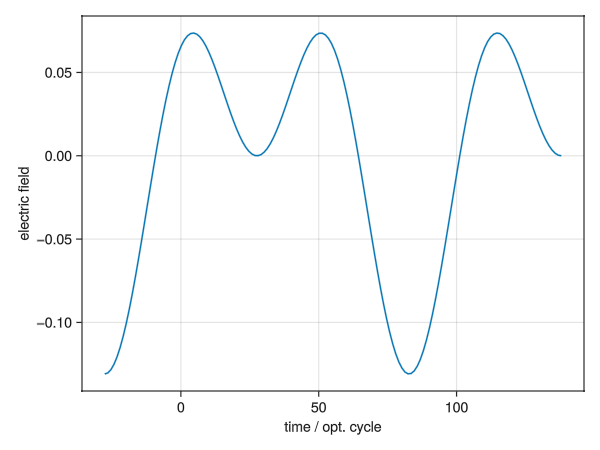

In [11]:
let # local scope block
   
    beam = beam_twob
    
    TC = TCycle(beam) # 1 optical cycle = 2π/ω
    times = range(-0.25TC, stop = 1.25*TC, length = 150)
    
    efield = [E(beam)(t)[1] for t in times]
    
    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "electric field"
    ) 
    
    lines!(ax, times, efield)

    f
end

In [24]:
TCycle(beam_twob)

110.34838917559546

### convenience function to make different beams

just as an example, if you were interested in how the HHG spectrum of a colinear two-colour field depends on the relative intensity of the two components, you could define yourself a function like this:

In [83]:
function beam_R(R::Number)
    ### ω-2ω, linearly polarised, no phase shift
    λ = 1030 # fundamental wavelength in nm
    I_total = 0.92e14;
    
    return BeamBETC(Intensity1 = I_total, Intensity2 = R/(1-R)*I_total,
        lambda=λ, r = 1, s = 2, epsilon = 0., phi = 0.)
end

beam_R (generic function with 1 method)

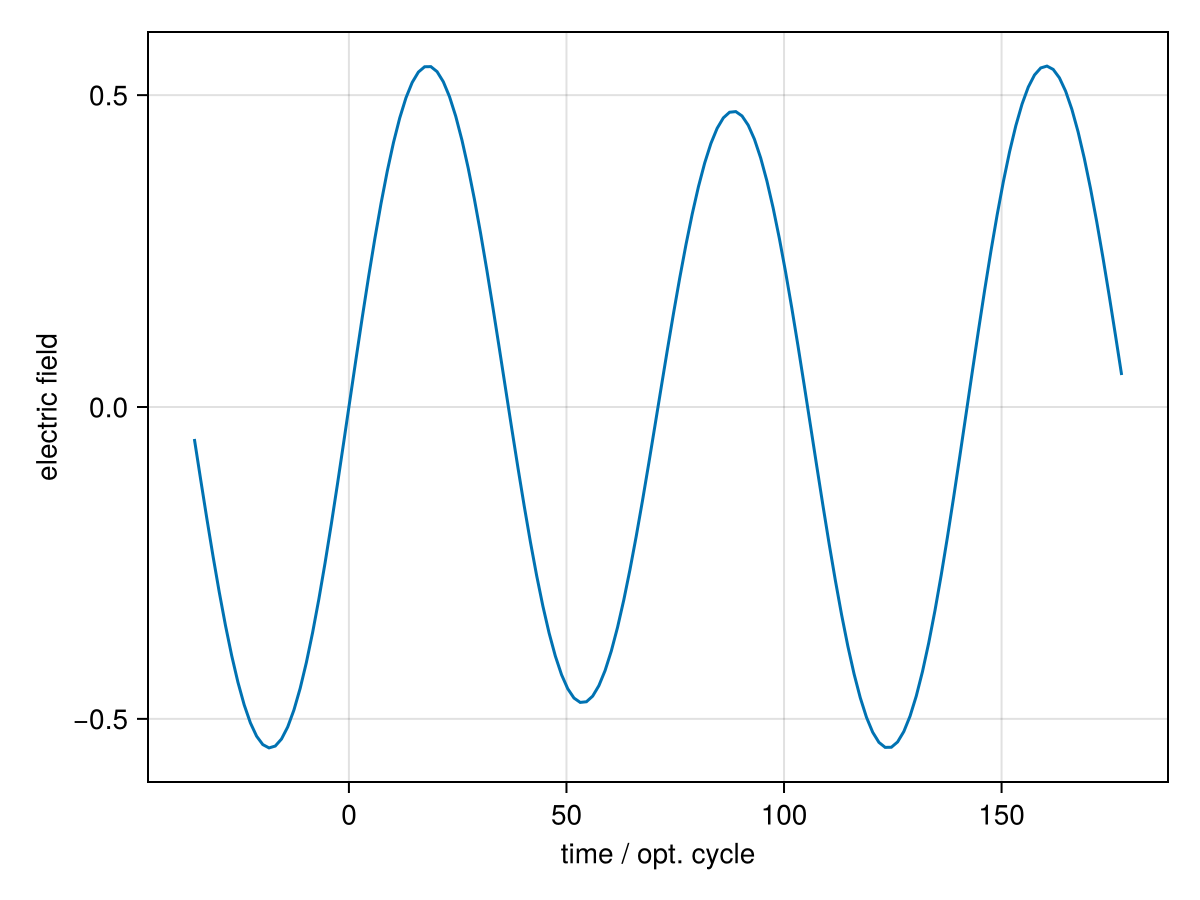

In [84]:
let # local scope block
    beam = beam_R(0.99)
    
    TC = TCycle(beam) # 1 optical cycle = 2π/ω
    times = range(-0.25TC, stop = 1.25*TC, length = 150)

    efield = [E(beam)(t)[1] for t in times]

    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "electric field"
    ) 

    lines!(ax, times, efield)

    f
end

# target

This code is for hydrogenic targets only, and we're working within the SFA, so all we use to describe the target is its ionisation potential `Ip`, in atomic units.

In [11]:
const Ip = IpAU(15.7596) # Argon gas target, we will keep this constant

0.5791543250255408

In case you want to look at the classical solutions you can set $I_p = 0$.

In [14]:
const Ip_class = 0.0;

# which harmonic orders?

which harmonic orders to consider?

In [21]:
Ip/get_omega(λ) # 1030 nm fundamental wavelength

10.171392968089176

In [22]:
(Ip + 3.17*get_Up(beam_twob))/get_omega(λ)

33.16943625971628

In [12]:
q_values = collect(11:50);

# convenience functions

In [13]:
function action_functions(b::Beam, Ip::Number, q::Number)
        action(ti, tr) = -im*S(b, Ip, ti, tr, q)
        action_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
        action_hessian(ti,tr) = my_hessian(b, Ip, q, ti, tr)
    return action, action_grad, action_hessian
end

action_functions (generic function with 1 method)

In [14]:
import Base.in
function in(x::Real, xmin::Real, xmax::Real; inclusive::Bool=true)
    if inclusive
        return xmin <= x <= xmax
    else
        return xmin < x < xmax
    end
end;

In [ ]:
# function threaded_loop    all = Vector{Tuple{Saddle,Bool}}()

#     ib_lims = get_ionisationburst_limits(b, Ip, q_values)

#     for (idx,lims) in enumerate(ib_lims)
        
#         ti_cd = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
#         tr_cd = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        
#         results = [Vector{Vector}() for _ in 1:Threads.nthreads()]

#         Threads.@threads for q in q_values[1:3]
#             data_thread = Vector{Tuple{Saddle,Bool}}()
            
#             saddles = find_saddles_sobol(q; b = b, Ip = Ip,
#             for s in saddles
#                 rel = check_contribution(action_functions(b, Ip, q)..., s.ti, s.tr)
#                 ### if you want to save time, just do this instead
#         #             rel = true 

#                 push!(data_thread, (s, rel))
#             end        

#             push!(results[Threads.threadid()], data_thread)
#         end

#         [[push!(all, vec...) for vec in r] for r in results]

# ionisation bursts

In [15]:
include(pathtosrc*"/header/ionisationbursts.jl")

get_ionisationburst_limits (generic function with 2 methods)

# all (unstructured saddle points)

### first attempt

In [26]:
data_all = let
    b = beam_twob
    
    TC = TCycle(b)
    all = Vector{Tuple{Saddle,Bool}}()

    ib_lims = get_ionisationburst_limits(b, Ip, q_values)

    for (idx,lims) in enumerate(ib_lims)
        
        ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
        tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        
        results = [Vector{Vector}() for _ in 1:Threads.nthreads()]

        Threads.@threads for q in q_values
            data_thread = Vector{Tuple{Saddle,Bool}}()
            
            saddles = find_saddles_sobol(q; b = b, Ip = Ip,ti_cd=ti_domain, tr_cd=tr_domain)
            for s in saddles
                rel = check_contribution(action_functions(b, Ip, q)..., s.ti, s.tr)
                ### if you want to save time, just do this instead
        #             rel = true 

                push!(data_thread, (s, rel))
            end        

            push!(results[Threads.threadid()], data_thread)
        end

        [[push!(all, vec...) for vec in r] for r in results]
    end

    all
end;

┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45


In [27]:
scr1 = GLMakie.Screen();

In [28]:
let
    b = beam_twob
    TC = TCycle(b)

    data = data_all

    fig = Figure(size = (800,400))
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 
    
    # ti in the complex plane
    [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
#             strokecolor = real(tup[1].q),
#             strokecolorrange = extrema(q_values), strokecolormap = :jet,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]
    
    [scatter!(ax2, [reim(tup[1].tr)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
#             strokecolor = real(tup[1].q),
#             strokecolorrange = extrema(q_values), strokecolormap = :jet,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]
    
    [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
#             strokecolor = real(tup[1].q),
#             strokecolorrange = extrema(q_values), strokecolormap = :jet,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]    
    
    display(scr1, fig)    
      
end

GLMakie.Screen(...)

all saddle points:
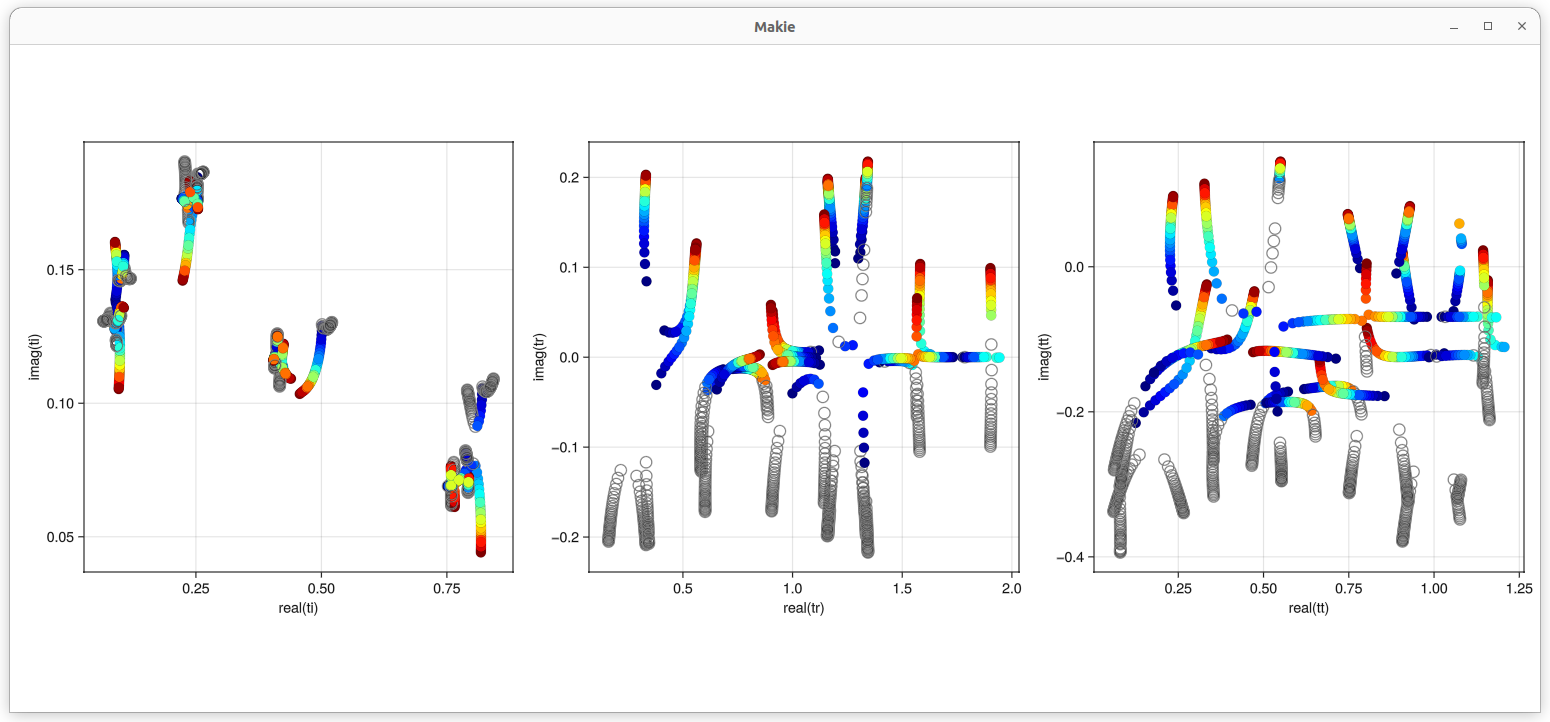

### plot per ionisation burst

In [29]:
ionisationbursts_twob = get_ionisationburst_limits(beam_twob, Ip, q_values)

4-element Vector{Tuple{Float64, Float64}}:
 (-0.05327848128750001, 0.17077730033750002)
 (0.17077730033750002, 0.329229998475)
 (0.329229998475, 0.631363996525)
 (0.631363996525, 0.9467215187125)

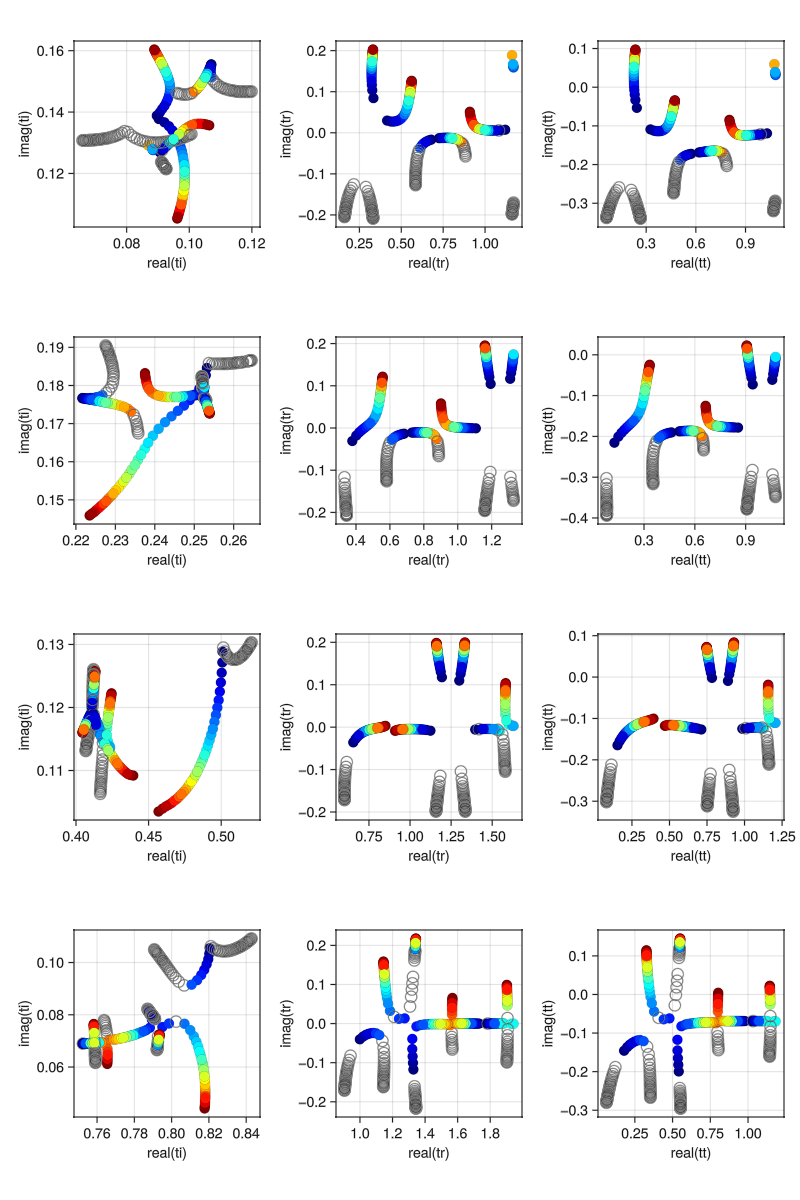

In [63]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 1200))
    
    for ib in 1:length(ionisationbursts_twob)
        
        data = filter(tup -> in(real(tup[1].ti/TC ),ionisationbursts_twob[ib]... ), data_all)

        ax1 = Axis(fig[ib, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
        ax2 = Axis(fig[ib, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
        ax3 = Axis(fig[ib, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

        # ionisation times
        [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
                color = tup[2] ? real(tup[1].q) : :transparent,
                markersize = 15, 
                strokecolor = tup[2] ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for tup in data]
        
        # recombination times
        [scatter!(ax2, [reim(tup[1].tr)./TC],
                color = tup[2] ? real(tup[1].q) : :transparent,
                markersize = 15, 
                strokecolor = tup[2] ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for tup in data]

        # travel times
        [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
                color = tup[2] ? real(tup[1].q) : :transparent,
                markersize = 15, 
                strokecolor = tup[2] ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for tup in data]    
    end
    fig
    
#     display(scr1, fig)    
      
end

Conclusion: Yes, I think it's fair to assume that within each IB the saddle points look kinda similar, at least the first pair of S+L.

### inspecting IB 3

In [257]:
test_data_ib3 = let
    b = beam_twob
    
    TC = TCycle(b)
    all = Vector{Tuple{Saddle,Bool}}()

    ib_lims = get_ionisationburst_limits(b, Ip, q_values)

    lims = ib_lims[3]
#     for (idx,lims) in enumerate(ib_lims)
        
        ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
        tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        
        results = [Vector{Vector}() for _ in 1:Threads.nthreads()]

        Threads.@threads for q in range(minimum(q_values), stop = 55, step =1.)
            data_thread = Vector{Tuple{Saddle,Bool}}()
            
            saddles = find_saddles_sobol(q; b = b, Ip = Ip,ti_cd=ti_domain, tr_cd=tr_domain)
            for s in saddles
                rel = check_contribution(action_functions(b, Ip, q)..., s.ti, s.tr)
                ### if you want to save time, just do this instead
        #             rel = true 

                push!(data_thread, (s, rel))
            end        

            push!(results[Threads.threadid()], data_thread)
        end

        [[push!(all, vec...) for vec in r] for r in results]
#     end

    all
end;

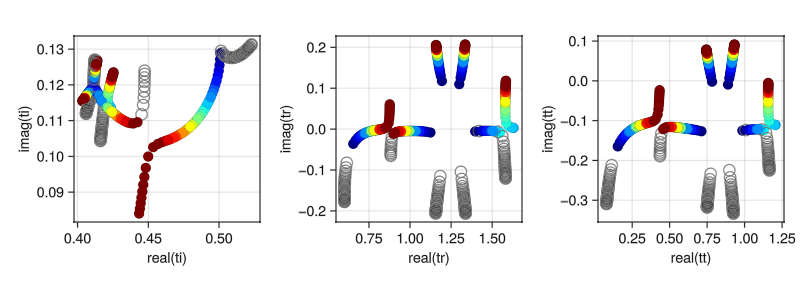

In [259]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 300))
           
    data = test_data_ib3

    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    # ionisation times
    [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]

    # recombination times
    [scatter!(ax2, [reim(tup[1].tr)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]

    # travel times
    [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]    
    fig
    
#     display(scr1, fig)    
      
end

# searching / classifying within each IB

In [82]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 300))
    ib = 4
        
    data = filter(tup -> in(real(tup[1].ti/TC ),ionisationbursts_twob[ib]... ), data_all)

    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    # ionisation times
    [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]

    # recombination times
    [scatter!(ax2, [reim(tup[1].tr)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]

    # travel times
    [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]    
#     fig
    
    ### highlight a saddle point in the plateau
    q_select = q_values[Int(round(length(q_values)/2))]
    data_q_select = filter(tup -> tup[1].q == q_select, data)
    
    # ionisation times
    [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
            marker = :x,
            color = q_select, colorrange = extrema(q_values), colormap = :jet,
            strokecolor = :black, strokewidth = 1,
            markersize = 15) for tup in data_q_select]

    # recombination times
    [scatter!(ax2, [reim(tup[1].tr)./TC],
            marker = :x,
            color = q_select, colorrange = extrema(q_values), colormap = :jet,
            strokecolor = :black, strokewidth = 1,
            markersize = 15) for tup in data_q_select]

    # travel times
    [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
            marker = :x,
            color = q_select, colorrange = extrema(q_values), colormap = :jet,
            strokecolor = :black, strokewidth = 1,
            markersize = 15) for tup in data_q_select] 

    
#     fig
   
    display(scr1, fig)    
end

GLMakie.Screen(...)

## find saddle points within the plateau and within 1TC

In [84]:
TC = TCycle(beam_twob)

110.34838917559546

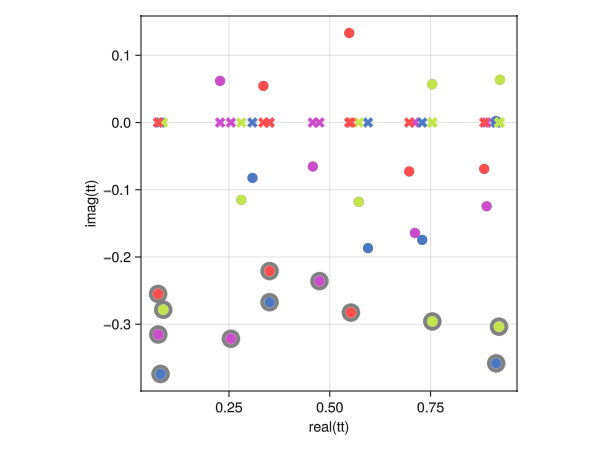

In [173]:
let
    fig = Figure()
    ax = Axis(fig[1, 1],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    data_test = Vector{Saddle}()
    for ib in 1:length(ionisationbursts_twob)
        data_ib = filter(tup -> in(real(tup[1].ti/TC ),ionisationbursts_twob[ib]... ), data_all)
        q_select = q_values[Int(round(length(q_values)/2))]

        saddles_selected_q = filter(tup -> tup[1].q == q_select, data_ib)
    #     for tup in saddles_selected
    #         s = tup[1]
    #         println(real(traveltime(s))/TC)
    #     end
    #     println()
        
        saddles_selected_tt = filter(tup-> real(traveltime(tup[1])) <= 1*TC, saddles_selected_q)
        for tup in saddles_selected_tt
            scatter!(ax, reim(traveltime(tup[1])/TC), markersize = 15,
                color = ib, colormap=:lightrainbow, colorrange=(1,4)
                , strokecolor = tup[2] ? :transparent : :grey, strokewidth = 4)
            scatter!(ax, (real(traveltime(tup[1])/TC),0), marker = :x, markersize = 15,
                color = ib, colormap=:lightrainbow, colorrange=(1,4))
        end
        
#         display()
    end
    fig
end

Actually, I will filter out the one with tt < 0.2TC as well.

## within one IB, for each initial saddle trace lines across qrange

### structs, functions

In [16]:
struct ClassifiedSaddle1
    s::Saddle
    tag::Int
    relevant::Bool
end

In [17]:
function trace_saddle_across_q(s::Saddle, qmin::Number, qmax::Number;
        b::Beam, Ip::Real, qstep::Number=1.,
        beam::Beam=b )
    
    ### now iterate to above
    s_init = s
    q_init = s.q
    saddles = [s_init] # better julia would be to define that array beforehand and then just fill it
    
    TC = TCycle(b)
    
    ### to above
    for q in range(q_init, stop = qmax, step = qstep)
        seed = saddles[end]
        ti_domain = ComplexDomain(real(seed.ti)/TC - 0.2, real(seed.ti)/TC + 0.2, 0.01,0.35)*TC;
        tr_domain = ComplexDomain(real(seed.tr)/TC - 0.3, real(seed.tr)/TC + 0.3, -0.35,0.35)*TC;
        next = find_saddle_similar_seed(q, seed, b=beam, Ip=Ip, ti_cd = ti_domain, tr_cd = tr_domain)
        push!(saddles, next)
    end
    push!(saddles, s_init)
    
    ### to below
    for q in range(q_init, stop = qmin, step = -qstep)
        seed = saddles[end]
        ti_domain = ComplexDomain(real(seed.ti)/TC - 0.2, real(seed.ti)/TC + 0.2, 0.01,0.35)*TC;
        tr_domain = ComplexDomain(real(seed.tr)/TC - 0.3, real(seed.tr)/TC + 0.3, -0.35,0.35)*TC;
        next = find_saddle_similar_seed(q, seed, b=beam, Ip=Ip, ti_cd = ti_domain, tr_cd = tr_domain)
        push!(saddles, next)
    end
    deleteat!(saddles, 1)
    sort!(saddles, by = s -> s.q)

    saddles   
end

trace_saddle_across_q (generic function with 1 method)

### doing it

In [261]:
data_classified_saddles = let
    beam = beam_twob

    data_test = Vector{ClassifiedSaddle1}()
    for ib in 1:length(ionisationbursts_twob)
        data_ib = filter(tup -> in(real(tup[1].ti/TC ),ionisationbursts_twob[ib]... ), data_all)
        q_select = q_values[Int(round(length(q_values)/2))]

        saddles_init = sort(filter(
            tup -> tup[1].q == q_select && 0.2*TC <= real(traveltime(tup[1])) <= 1*TC           
            , data_ib)
            , by = tup -> real(traveltime(tup[1])) )
        if length(saddles_init) != 6
            @show ib
            @show length(saddles_init)
            
        end
            
        for (idx, tup) in enumerate(saddles_init)
            tag = ib*10 + idx
            
            saddles_trace = trace_saddle_across_q(tup[1], extrema(q_values)..., b = beam_twob, Ip = Ip)
            
            for s in saddles_trace
                # If you don't care about the relevance and just want the saddles quickly
#                 rel = true
                
                # or if you do (but this might take ages)
#                 ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
#                 tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
                rel = check_contribution(action_functions(beam, Ip, s.q)..., s.ti, s.tr)
           
                push!(data_test, ClassifiedSaddle1(s, tag, rel))
            end

    #         println(real(traveltime(s))/TC)
        end

    end
    data_test
end;

┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45


## plotting the classified saddle points per IB

### utils

In [187]:
tag_colors = let
#     tags = sort(filter(t -> !in(t, [:Mclose, :Oclose, :Mnew, :Onew]), unique(SWI_df_phisw.tag_con)))
    
    ### expected number of saddles per IB
    ns = 6
    
    ### number of ionisationbursts
    ni = 4
    
    tags = [i*10+j for i in 1:ni for j in 1:ns]
    @show tags
    collength = ns+1
    colmap = :lightrainbow #:Set1_9 # Makie.wong_colors()
    tag_colors = Dict([(tag, cgrad(colmap, collength, categorical = true)[tag%10]) 
            for tag in tags])
    for t in setdiff(1:50, tags)
        tag_colors[t] = Makie.to_color(:grey)
    end
    tag_colors
end;

tags = [11, 12, 13, 14, 15, 16, 21, 22, 23, 24, 25, 26, 31, 32, 33, 34, 35, 36, 41, 42, 43, 44, 45, 46]


In [186]:
cgrad(:lightrainbow, 7, categorical = true)

In [188]:
tag_colors[15]

In [189]:
tag_colors[16]

In [ ]:
# unique([cs.tag for cs in data_classified_saddles])

### plot from data_classified_saddles - per IB

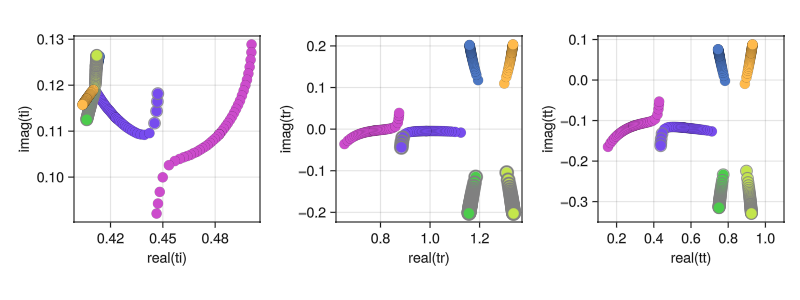

In [262]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 300))
    ib = 3
        
    data_cs = filter(cs -> div(cs.tag, 10) == ib , data_classified_saddles)
    
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

#     color_cs(cs::ClassifiedSaddle1) = cs.relevant ? real(cs.s.q) : :transparent
    color_cs(cs::ClassifiedSaddle1) = tag_colors[cs.tag]

#     # ionisation times
    [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # recombination times
    [scatter!(ax2, [reim(cs.s.tr)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 2,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # travel times
    [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
    
    xlims!(ax3, 0.1, 1.1)
    
    fig
#     display(scr1, fig)    
end

### plot classified data for all IBs

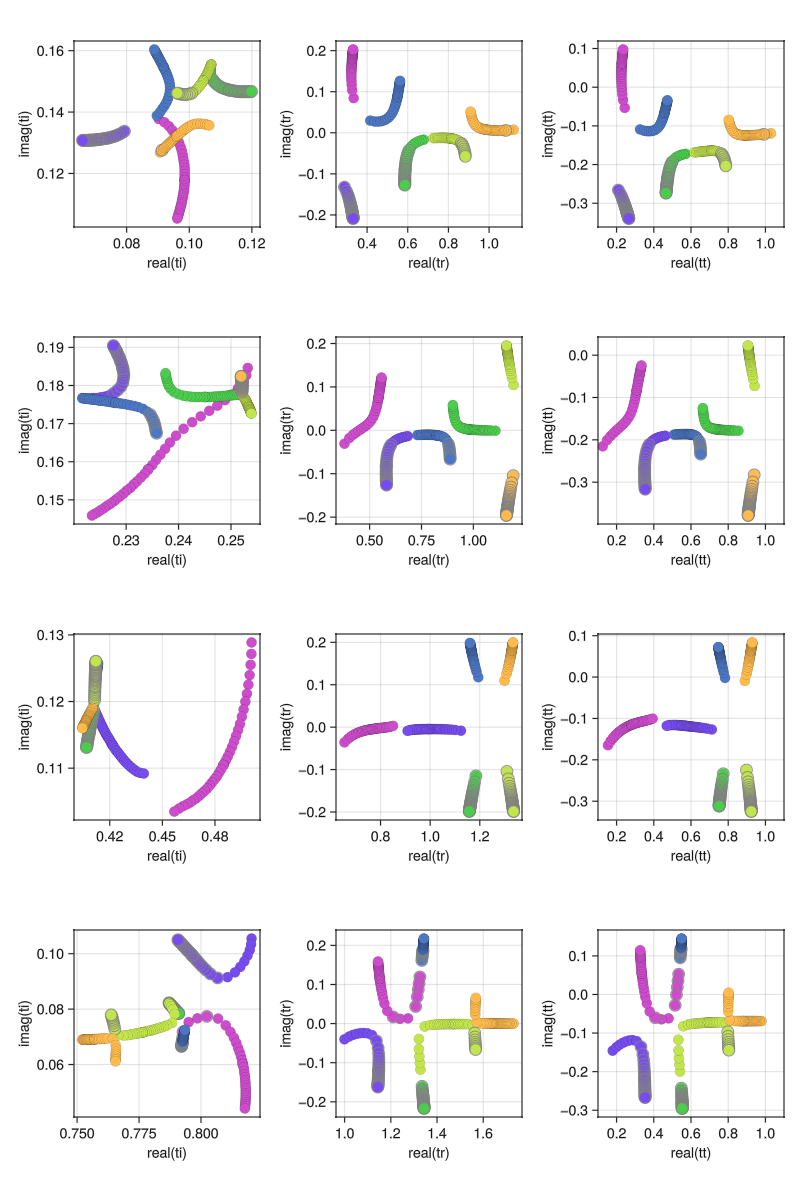

In [250]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 1200))
    
    for ib in 1:4
        
        data_cs = filter(cs -> div(cs.tag, 10) == ib , data_classified_saddles)

        ax1 = Axis(fig[ib, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
        ax2 = Axis(fig[ib, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
        ax3 = Axis(fig[ib, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    #     color_cs(cs::ClassifiedSaddle1) = cs.relevant ? real(cs.s.q) : :transparent
        color_cs(cs::ClassifiedSaddle1) = tag_colors[cs.tag]

    #     # ionisation times
        [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
                color = color_cs(cs),
                markersize = 15, 
                strokecolor = cs.relevant ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

        # recombination times
        [scatter!(ax2, [reim(cs.s.tr)./TC],
                color = color_cs(cs),
                markersize = 15, 
                strokecolor = cs.relevant ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

        # travel times
        [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
                color = color_cs(cs),
                markersize = 15, 
                strokecolor = cs.relevant ? :transparent : :grey,
                strokewidth = 1,
                colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
        xlims!(ax3, 0.1, 1.1)
    end
    fig
#     display(scr1, fig)
end

# calculate dipoles for classified saddles

## for a given harmonic order

In [212]:
let
    q = 29.
    b = beam_twob

    S_f, S_grad, S_hessian = action_functions(b, Ip, q)
    
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
#         ti = tvec[1]; tr = tvec[2]
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end

    ### find the respective saddles in the big data array of classified saddles
    saddles_q = filter(cs-> cs.s.q == q, data_classified_saddles)
    
    int_spm = zeros(ComplexF64,2) # sum over gaussian contributions
    
    for cs in saddles_q
        if cs.relevant
            println(cs.s)
            int_spm_s = saddles_gaussian_contribution(S_f, S_hessian, cs.s.ti, cs.s.tr, prefactor = prefactor)
            int_spm .+= int_spm_s
            
            @show int_spm_s
            println()
        end
    end
    @show int_spm
end

ti: 10.87 + 12.9im, tr: 36.07 + 20.05im, q29.0
int_spm_s = ComplexF64[7.17254745679096e-13 + 1.7456032570287767e-13im, 0.0 + 0.0im]

ti: 7.77 + 14.45im, tr: 35.97 - 21.19im, q29.0
int_spm_s = ComplexF64[4456.649673790304 - 6655.313030579084im, 0.0 + 0.0im]

ti: 10.1 + 17.12im, tr: 60.8 + 10.22im, q29.0
int_spm_s = ComplexF64[2.1248476840755873e-8 + 8.760266717306502e-9im, 0.0 - 0.0im]

ti: 12.5 + 16.23im, tr: 64.74 - 10.17im, q29.0
int_spm_s = ComplexF64[2.3906460492630116e-5 + 4.0799348621140785e-5im, -0.0 + 0.0im]

ti: 11.51 + 16.54im, tr: 90.49 - 1.59im, q29.0
int_spm_s = ComplexF64[-3.592606219341964e-8 + 4.144175333837736e-7im, -0.0 + 0.0im]

ti: 10.63 + 14.61im, tr: 108.16 + 0.88im, q29.0
int_spm_s = ComplexF64[-5.606692017344646e-6 + 1.2135838132459735e-6im, -0.0 + 0.0im]

ti: 25.77 + 17.31im, tr: 60.03 + 8.82im, q29.0
int_spm_s = ComplexF64[6.25185584683384e-8 + 3.363531760225819e-8im, -0.0 + 0.0im]

ti: 25.3 + 20.41im, tr: 63.99 - 9.59im, q29.0
int_spm_s = ComplexF64[6.9977786

2-element Vector{ComplexF64}:
 -62782.240042650716 - 11427.430602033994im
                 0.0 + 0.0im

## the full spectrum

### Dipole struct, functions

In [55]:
struct ClassifiedDipole1
    q::Number
    dip::Vector{ComplexF64}
    tag::Int
    relevant::Bool
    int::Float64
end

### calculating all the dipoles

In [263]:
data_classified_dipoles = let
    data = Vector{ClassifiedDipole1}()
    
    b = beam_twob
   
    for q in q_values
        
        S_f, S_grad, S_hessian = action_functions(b, Ip, q)

        function prefactor(ti,tr)
            ### eq. 5 from Emilio's thc paper
    #         ti = tvec[1]; tr = tvec[2]
            ps = p_stationary(b, ti, tr)
            dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)

            fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
            traveltime = tr - ti

            prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
            prefactor_const *= fontaine_SR_m0

            return prefactor_const * dip_r
        end        

        saddles_q = filter(cs-> cs.s.q == q, data_classified_saddles)
    
        for cs in saddles_q
            dip_s = saddles_gaussian_contribution(S_f, S_hessian, cs.s.ti, cs.s.tr, prefactor = prefactor)
            intensity = harmonic_intensity(b, dip_s, cs.s.q)
            push!(data, ClassifiedDipole1(cs.s.q, dip_s, cs.tag, cs.relevant, intensity))
        end 
    end
    data
end;

### plot all the intensities

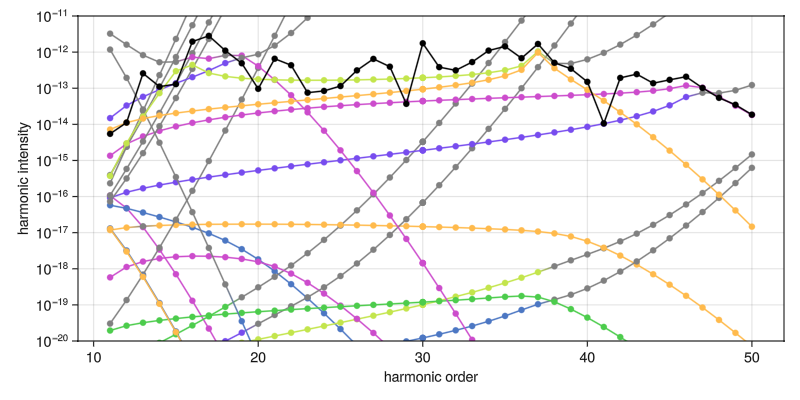

In [264]:
let
    beam = beam_twob
    f = Figure(size=(800,400))
    ax = Axis(f[1, 1], 
        yscale = log10, 
        xlabel = "harmonic order", ylabel = "harmonic intensity" ) 
    
    ### for each tag separately
    tags = unique([cd.tag for cd in data_classified_dipoles])
    
    for tag in tags
        data_tag = sort(filter(cd -> cd.tag == tag, data_classified_dipoles), by = cd -> cd.q)
        
        scatterlines!(ax, [(cd.q, cd.int) for cd in data_tag]
            , color = [cd.relevant ? tag_colors[tag] : :grey for cd in data_tag]
            )
    end
    
    total_intensity = [
        harmonic_intensity(beam,
            ### dipole
            sum([cd.dip for cd in
            filter(cd-> cd.relevant && cd.q ==q, data_classified_dipoles) # relevant dipoles for this q
            ]), q)
        for q in q_values
    ]
    
#     @show total_intensity
    scatterlines!(ax, q_values, total_intensity, color = :black)
    
    ylims!(ax, (1e-20,1e-11))

#     f[1,2] = Legend(f, ax)
    f
end

# make one function that gets all classified data for a given beam

## get_classified_saddles()

In [53]:
function get_classified_saddles(beam::Beam, Ip::Number, q_values::Vector{T};
        ionisationbursts::Vector{Tuple{Float64, Float64}} = get_ionisationburst_limits(beam, Ip, q_values),
        q_init::Real=q_values[Int(round(length(q_values)/2))],
        calculate_relevance::Bool=true
        ) where T<:Real
    
    TC = TCycle(beam)
    
    data = Vector{ClassifiedSaddle1}()
    for (ib, lims) in enumerate(ionisationbursts)
        
        ### for q_init (~ a harmonic order in the plateau), find all saddle points from this IB
        
        ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
        tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        saddles = find_saddles_sobol(q_init; b = beam, Ip = Ip,ti_cd=ti_domain, tr_cd=tr_domain)
        
        ### select those with reasonable travel time
        saddles_init = sort(
            filter(s -> in(real(traveltime(s)), 0.2*TC,  1*TC) &&
                in(real(s.ti)/TC, lims...),
                saddles)
            , by = s -> real(traveltime(s)) )
        
        @assert length(saddles_init) == 6
        
        ### for each of the saddles, find saddles for the remaining harmonic orders
        for (idx, s_init) in enumerate(saddles_init)
            tag = ib*10 + idx # this is now my naming convention for the tag of each trajectory

            saddles_trace = trace_saddle_across_q(s_init, extrema(q_values)..., b = beam, Ip = Ip)

            for s in saddles_trace
                if calculate_relevance
                    rel = check_contribution(action_functions(beam, Ip, s.q)..., s.ti, s.tr)
                    push!(data, ClassifiedSaddle1(s, tag, rel))
                else
                    push!(data, ClassifiedSaddle1(s, tag, true))
                end

            end

    #         println(real(traveltime(s))/TC)
        end

    end
    data
end

get_classified_saddles (generic function with 6 methods)

In [56]:
classified_saddles = get_classified_saddles(beam_twob, Ip, q_values,q_init=20. , calculate_relevance=false)

1008-element Vector{ClassifiedSaddle1}:
 ClassifiedSaddle1(ti: 9.96 + 15.2im, tr: 36.85 + 9.31im, q11.0, 11, true)
 ClassifiedSaddle1(ti: 10.16 + 15.08im, tr: 36.08 + 11.44im, q12.0, 11, true)
 ClassifiedSaddle1(ti: 10.32 + 14.94im, tr: 35.78 + 12.86im, q13.0, 11, true)
 ClassifiedSaddle1(ti: 10.44 + 14.79im, tr: 35.66 + 13.94im, q14.0, 11, true)
 ClassifiedSaddle1(ti: 10.54 + 14.63im, tr: 35.61 + 14.79im, q15.0, 11, true)
 ClassifiedSaddle1(ti: 10.61 + 14.48im, tr: 35.6 + 15.51im, q16.0, 11, true)
 ClassifiedSaddle1(ti: 10.68 + 14.34im, tr: 35.61 + 16.11im, q17.0, 11, true)
 ClassifiedSaddle1(ti: 10.73 + 14.19im, tr: 35.63 + 16.64im, q18.0, 11, true)
 ClassifiedSaddle1(ti: 10.77 + 14.06im, tr: 35.67 + 17.11im, q19.0, 11, true)
 ClassifiedSaddle1(ti: 10.8 + 13.92im, tr: 35.71 + 17.53im, q20.0, 11, true)
 ClassifiedSaddle1(ti: 10.8 + 13.92im, tr: 35.71 + 17.53im, q20.0, 11, true)
 ClassifiedSaddle1(ti: 10.8 + 13.92im, tr: 35.71 + 17.53im, q20.0, 11, true)
 ClassifiedSaddle1(ti: 10.82 + 

## get_classified_dipoles()

In [57]:
function get_classified_dipoles(beam::Beam, Ip::Number, q_values::Vector{T},
        classified_saddles::Vector{ClassifiedSaddle1}) where T<:Real
    
    TC = TCycle(beam)

    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
        ps = p_stationary(beam, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(beam)(tr), Ip)

        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    
    
    data = Vector{ClassifiedDipole1}()
    
    for q in q_values
        S_f, S_grad, S_hessian = action_functions(beam, Ip, q)

        saddles_q = filter(cs-> cs.s.q == q, classified_saddles)
    
        for cs in saddles_q
            dip_s = saddles_gaussian_contribution(S_f, S_hessian, cs.s.ti, cs.s.tr, prefactor = prefactor)
            intensity = harmonic_intensity(beam, dip_s, cs.s.q)
            push!(data, ClassifiedDipole1(cs.s.q, dip_s, cs.tag, cs.relevant, intensity))
        end 
    end
    data 
end

get_classified_dipoles (generic function with 1 method)

In [58]:
classified_dipoles = get_classified_dipoles(beam_twob, Ip, q_values, classified_saddles)

1008-element Vector{ClassifiedDipole1}:
 ClassifiedDipole1(11.0, ComplexF64[-7.32127045009877e-5 + 7.596391633108878e-5im, -0.0 + 0.0im], 11, true, 1.0602392543879761e-16)
 ClassifiedDipole1(11.0, ComplexF64[6.835296610268436e-5 + 0.00019167949360590826im, 0.0 + 0.0im], 12, true, 3.944781780005025e-16)
 ClassifiedDipole1(11.0, ComplexF64[1.3390789374119684e-5 - 7.654883556440456e-5im, 0.0 + 0.0im], 13, true, 5.752443698217521e-17)
 ClassifiedDipole1(11.0, ComplexF64[3.6744691561255263e-7 - 4.109894462743608e-8im, -0.0 + 0.0im], 14, true, 1.3021870421668041e-21)
 ClassifiedDipole1(11.0, ComplexF64[7.73609859801325e-9 + 3.034183827568891e-7im, 0.0 + 0.0im], 15, true, 8.775071448714517e-22)
 ClassifiedDipole1(11.0, ComplexF64[2.7025161304915313e-5 - 2.2584028403539204e-5im, 0.0 + 0.0im], 16, true, 1.1815323007514256e-17)
 ClassifiedDipole1(11.0, ComplexF64[-6.6660049301109055e-6 + 4.027748109222876e-6im, 0.0 + 0.0im], 21, true, 5.777972034947356e-19)
 ClassifiedDipole1(11.0, ComplexF64[-4